# BAN130 Assignment 2 – Final Group Submission
## Group 2 Final Notebook

This notebook combines Parts 1 through 5 from the repository into a single final submission.
Each part preserves the original code, comments, and outputs as closely as possible.

**Datasets used:** `eu_occ.sas7bdat`, `np_summary.sas7bdat`, `customer.sas7bdat`

**Notes:**
- Part 1 author: Fangfang Lin
- Part 2 author: Ayman Rahman
- Part 3 author: Emmanuelle Calixe Mbeleg
- Part 4 author: Henry Truong
- Part 5 author: Kristi Molle 


## Part 1: Exploring and Filtering Data

**Member:** Fangfang Lin  
**Dataset:** EU_OCC

In [1]:
import pandas as pd


### Step 1: Load the dataset and examine the columns and values
SAS stores text columns as bytes (e.g. `b'Austria'`), so we decode them into normal strings before filtering.


In [2]:
# Load the EU_OCC dataset
df = pd.read_sas('eu_occ.sas7bdat')

# Decode byte-string columns into normal text
for col in df.select_dtypes('object').columns:
    df[col] = df[col].str.decode('utf-8')

# Examine the columns and values
print('Column names:', list(df.columns))
print('Shape (rows, columns):', df.shape)
print('\nFirst 5 rows:')
print(df.head())


Column names: ['Geo', 'Country', 'YearMon', 'Hotel', 'ShortStay', 'Camp']
Shape (rows, columns): (4785, 6)

First 5 rows:
  Geo  Country  YearMon       Hotel  ShortStay       Camp
0  AT  Austria  2017M09   7768564.0  1453530.0   524121.0
1  AT  Austria  2017M08  11353432.0  3140217.0  1997801.0
2  AT  Austria  2017M07  10124106.0  2836425.0  1752605.0
3  AT  Austria  2017M06   7391827.0  1568683.0   914560.0
4  AT  Austria  2017M05   5068884.0  1054870.0   359560.0


### Step 2: Filter to rows where YearMon starts with "2016"
`YearMon` looks like `2016M12`, so we keep every row that starts with `2016`.


In [3]:
df_2016 = df[df['YearMon'].str.startswith('2016')].copy()
print('Rows after filtering for 2016:', df_2016.shape[0])
print(df_2016.head())


Rows after filtering for 2016: 348
   Geo  Country  YearMon       Hotel  ShortStay       Camp
9   AT  Austria  2016M12   6670483.0  1468847.0   117579.0
10  AT  Austria  2016M11   3600616.0   681867.0    28303.0
11  AT  Austria  2016M10   5727389.0   985402.0   146108.0
12  AT  Austria  2016M09   7726801.0  1443829.0   620032.0
13  AT  Austria  2016M08  11399594.0  3022261.0  1897979.0


### Step 3: Format Hotel, ShortStay and Camp with thousand separators
`f'{x:,.0f}'` adds commas and keeps zero decimals. Note this converts the three columns to strings, which is the required display format.


In [4]:
for col in ['Hotel', 'ShortStay', 'Camp']:
    df_2016[col] = df_2016[col].apply(lambda x: f'{x:,.0f}')

print(df_2016.head())


   Geo  Country  YearMon       Hotel  ShortStay       Camp
9   AT  Austria  2016M12   6,670,483  1,468,847    117,579
10  AT  Austria  2016M11   3,600,616    681,867     28,303
11  AT  Austria  2016M10   5,727,389    985,402    146,108
12  AT  Austria  2016M09   7,726,801  1,443,829    620,032
13  AT  Austria  2016M08  11,399,594  3,022,261  1,897,979


### Step 4: Drop the Geo column


In [5]:
df_2016 = df_2016.drop(columns='Geo')

print('Final columns:', list(df_2016.columns))
print('\nFinal result (first 10 rows):')
print(df_2016.head(10).to_string(index=False))


Final columns: ['Country', 'YearMon', 'Hotel', 'ShortStay', 'Camp']

Final result (first 10 rows):
Country YearMon      Hotel ShortStay      Camp
Austria 2016M12  6,670,483 1,468,847   117,579
Austria 2016M11  3,600,616   681,867    28,303
Austria 2016M10  5,727,389   985,402   146,108
Austria 2016M09  7,726,801 1,443,829   620,032
Austria 2016M08 11,399,594 3,022,261 1,897,979
Austria 2016M07  9,996,416 2,633,484 1,608,971
Austria 2016M06  6,444,485 1,287,244   569,242
Austria 2016M05  5,619,330 1,118,179   445,622
Austria 2016M04  4,272,536   889,815   104,499
Austria 2016M03  9,595,174 2,726,831   144,641


## Part 2: Creating and Formatting Columns

**Member:** Ayman Rahman  
**Dataset:** np_summary

In [6]:
# Part 2: Creating and Formatting Columns (np_summary)

# Step 1: Load the np_summary dataset
np2 = pd.read_sas('np_summary.sas7bdat')

# Decode byte-string columns into normal text
for col in np2.select_dtypes('object').columns:
    np2[col] = np2[col].str.decode('utf-8')

print("Loaded np_summary:", np2.shape)

# Step 2: SqMiles = Acres * 0.0015625
np2['SqMiles'] = np2['Acres'] * 0.0015625

# Step 3: Camping = sum of the four camping columns
camping_cols = ['OtherCamping', 'TentCampers', 'RVCampers', 'BackcountryCampers']
np2['Camping'] = np2[camping_cols].sum(axis=1)

# Step 4: Format SqMiles and Camping with commas and zero decimals
np2['SqMiles'] = np2['SqMiles'].apply(lambda x: f'{x:,.0f}')
np2['Camping'] = np2['Camping'].apply(lambda x: f'{x:,.0f}')

# Step 5: Keep only the required columns
final_cols = ['Reg', 'ParkName', 'DayVisits', 'OtherLodging', 'Acres', 'SqMiles', 'Camping']
np2_final = np2[final_cols].copy()

# Save the processed dataset
np2_final.to_csv('np_summary_processed.csv', index=False)

print("\nFinal columns:", list(np2_final.columns))
print("\nFirst 5 rows:")
print(np2_final.head())


Loaded np_summary: (135, 10)

Final columns: ['Reg', 'ParkName', 'DayVisits', 'OtherLodging', 'Acres', 'SqMiles', 'Camping']

First 5 rows:
  Reg                                ParkName  DayVisits  OtherLodging  \
0   A      Cape Krusenstern National Monument    15000.0           0.0   
1   A              Kenai Fjords National Park   346534.0           0.0   
2   A              Kobuk Valley National Park    15500.0           0.0   
3   A  Yukon-Charley Rivers National Preserve     1146.0           0.0   
4   A    Bering Land Bridge National Preserve     2642.0           0.0   

        Acres SqMiles Camping  
0   649096.15   1,014   6,375  
1   669650.05   1,046   2,162  
2  1750716.16   2,735   7,050  
3  2523512.44   3,943   3,063  
4  2697391.01   4,215   1,123  


## Part 3: Data Transformation and Reporting

**Member:** Emmanuelle Calixe Mbeleg  
**Dataset:** np_summary

In [7]:
# Import required libraries
import pandas as pd
import matplotlib.pyplot as plt

# Load SAS dataset
np_summary = pd.read_sas('np_summary.sas7bdat')

# Decode byte-string columns into normal text (so Type == 'NM' works correctly)
for col in np_summary.select_dtypes('object').columns:
    np_summary[col] = np_summary[col].str.decode('utf-8')

# Display first rows
print(np_summary.head())


  Reg Type                                ParkName  DayVisits  OtherLodging  \
0   A   NM      Cape Krusenstern National Monument    15000.0           0.0   
1   A   NP              Kenai Fjords National Park   346534.0           0.0   
2   A   NP              Kobuk Valley National Park    15500.0           0.0   
3   A  PRE  Yukon-Charley Rivers National Preserve     1146.0           0.0   
4   A  PRE    Bering Land Bridge National Preserve     2642.0           0.0   

   OtherCamping  TentCampers  RVCampers  BackcountryCampers       Acres  
0           0.0          0.0        0.0              6375.0   649096.15  
1           0.0       1514.0        0.0               648.0   669650.05  
2           0.0          0.0        0.0              7050.0  1750716.16  
3           0.0          0.0        0.0              3063.0  2523512.44  
4           0.0          0.0        0.0              1123.0  2697391.01  


  Type  ParkType
0   NM  Monument
1   NP      Park
2   NP      Park
3  PRE  Preserve
4  PRE  Preserve

Frequency Report:
ParkType
Monument    63
Park        51
Seashore    10
Preserve     8
River        3
Name: count, dtype: int64


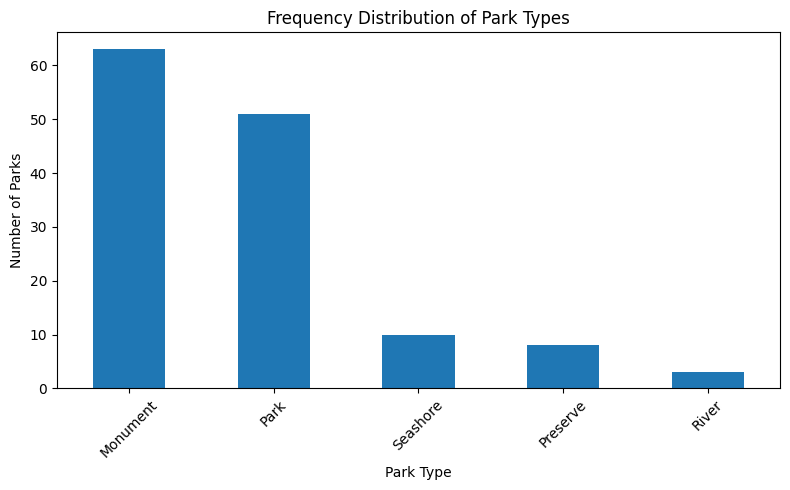

In [8]:
# Create ParkType column

def classify_park(row):
    if row['Type'] == 'NM':
        return 'Monument'
    elif row['Type'] == 'NP':
        return 'Park'
    elif row['Type'] in ['NPRE', 'PRE', 'PRESERVE']:
        return 'Preserve'
    elif row['Type'] == 'NS':
        return 'Seashore'
    elif row['Type'] in ['RVR', 'RIVERWAYS']:
        return 'River'
    else:
        return 'Other'

np_summary['ParkType'] = np_summary.apply(classify_park, axis=1)

# Show Type and ParkType columns
print(np_summary[['Type', 'ParkType']].head())

# Frequency report
park_frequency = np_summary['ParkType'].value_counts()

print('\nFrequency Report:')
print(park_frequency)

# Bar chart
plt.figure(figsize=(8,5))
park_frequency.plot(kind='bar')

plt.title('Frequency Distribution of Park Types')
plt.xlabel('Park Type')
plt.ylabel('Number of Parks')

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()


## Part 4: Advanced Queries and Data Formatting

**Member:** Henry Truong  
**Dataset:** customer

## Load the dataset and decode byte string columns


In [9]:
import pandas as pd
customer = pd.read_sas('customer.sas7bdat', encoding='latin1')


## Decode byte string columns and convert DOB to datetime


In [10]:
customer['DOB'] = pd.to_datetime(customer['DOB'], unit='D', origin='1960-01-01')


## Query 1

Filter customers where:
- BankID is missing
- CreditScore > 700

Sort by Income (descending) and display Income in dollar format.


In [11]:
filtered = customer[(customer['BankID'].isna()) & (customer['CreditScore'] > 700)]
filtered


,FirstName,MiddleName,LastName,Gender,DOB,Employed,Race,Married,StreetNumber,StreetName,...,Zip,HomePhone,CellPhone,StateID,UserID,CustomerID,BankID,Income,AccountID,CreditScore
0,Rodney,Matthew,Joyner,M,1966-01-11,Y,W,M,28.0,Davis Place,...,53001.0,(920)6982806,(920)6491939,WI62748437,rodmajoyner6611@n/a.com,1.902986e+09,NaN,63583.22,NaN,711.0
1,Jeanne,Carol,Ballenger,F,1963-06-08,N,H,NaN,236.0,Hillcrest Court,...,98074.0,NaN,NaN,WA56580527,jeacaballenger638@fakeemail.com,1.935367e+09,NaN,NaN,NaN,750.0
2,Brian,Dallas,Harper,M,1947-06-14,N,W,M,57.0,Oak Stanley Boulevard,...,53201.0,(414)7077277,(414)9037075,WI12094855,bridaharper4714@invalid.com,1.455003e+09,NaN,NaN,NaN,790.0
4,Becky,Danna,Cheers,F,1945-04-24,N,W,M,502.0,Meadow Lane,...,54720.0,(715)4864642,(715)0238456,WI66464214,becdacheers4524@n/a.com,1.914861e+09,NaN,NaN,NaN,716.0
12,Michael,Michael,Unger,M,1999-01-16,N,W,M,145.0,Sunflower Place,...,98101.0,(206)9850352,(206)4381473,WA65739547,micmiunger9916@fakeemail.com,1.910533e+09,NaN,NaN,NaN,705.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4918,Rachael,Naomi,Quiros,F,1969-03-23,N,H,S,44.0,3rd Street,...,60601.0,(312)5382937,(312)2692114,IL17847622,racnaquiros6923@invalid.com,1.978881e+09,NaN,NaN,NaN,706.0
4919,Melanie,Esperanza,Butler,F,1981-03-17,Y,W,M,403.0,Heritage Lane,...,60417.0,(708)9069919,NaN,IL88237247,melesbutler8117@invalid.com,1.938108e+09,NaN,73281.54,NaN,756.0
4926,Betty,Joan,Cercy,F,1964-02-22,N,W,NaN,574.0,Scott Court,...,66101.0,(913)0068252,(913)9349372,KS95840660,betjocercy6422@fakeemail.com,1.929606e+09,NaN,NaN,NaN,767.0
4928,Terry,Michael,Barbour,M,1953-12-22,N,W,D,26.0,Bluebird Court,...,60601.0,(312)4137667,NaN,IL28473518,termibarbour5322@invalid.com,1.909881e+09,NaN,NaN,NaN,719.0


In [12]:
filtered_sort = filtered.sort_values(by='Income', ascending=False)
filtered_sort['Income'] = filtered_sort['Income'].map('${:,.2f}'.format)
filtered_sort


,FirstName,MiddleName,LastName,Gender,DOB,Employed,Race,Married,StreetNumber,StreetName,...,Zip,HomePhone,CellPhone,StateID,UserID,CustomerID,BankID,Income,AccountID,CreditScore
3093,Wade,Michael,Estrade,M,1953-05-05,Y,W,S,526.0,Carter Court,...,55801.0,(218)4487453,(218)4208745,MN88992032,wadmiestrade535@n/a.com,1.963521e+09,NaN,"$102,435.14",NaN,790.0
1383,Chester,David,Dinora,M,1982-05-23,Y,H,M,3174.0,Partridge Pike Lane,...,95476.0,(707)1791108,(707)9685370,CA36445929,chedadinora8223@fakeemail.com,1.953324e+09,NaN,"$101,684.04",NaN,714.0
1942,Stella,Linda,Adams,F,1968-12-14,Y,B,M,1013.0,Stone Lane,...,75023.0,(214)6233623,(214)1201348,TX80226741,steliadams6814@notreal.com,1.923699e+09,NaN,"$96,699.91",NaN,704.0
1102,Lawrence,Sammy,Duval,M,1990-12-21,Y,W,D,14.0,Industrial Drive,...,92392.0,NaN,(760)5528820,CA05098737,lawsaduval9021@fakeemail.com,1.926969e+09,NaN,"$91,189.42",NaN,710.0
2034,Adam,Greg,Milonas,M,1985-02-03,Y,W,M,4002.0,Lewis Alcove,...,84003.0,(801)2613966,(801)1850205,UT56342465,adagrmilonas853@n/a.com,1.927561e+09,NaN,"$88,942.84",NaN,710.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4886,Kyle,Jason,Manzanilla,M,1996-11-18,N,W,M,68.0,Glen Trail,...,60126.0,NaN,NaN,IL89809286,kyljamanzanilla9618@fakeemail.com,1.939918e+09,NaN,$nan,NaN,729.0
4914,Cliff,Dennis,Jack,M,1953-09-10,N,W,M,241.0,Westwood Drive,...,60601.0,(312)9940905,(312)6584653,IL95210570,clidejack5310@isnull.com,1.985839e+09,NaN,$nan,NaN,727.0
4918,Rachael,Naomi,Quiros,F,1969-03-23,N,H,S,44.0,3rd Street,...,60601.0,(312)5382937,(312)2692114,IL17847622,racnaquiros6923@invalid.com,1.978881e+09,NaN,$nan,NaN,706.0
4926,Betty,Joan,Cercy,F,1964-02-22,N,W,NaN,574.0,Scott Court,...,66101.0,(913)0068252,(913)9349372,KS95840660,betjocercy6422@fakeemail.com,1.929606e+09,NaN,$nan,NaN,767.0


## Query 2

Filter rows where:
- DOB is earlier than 1940-12-31
- Employed equals "Y"

Sort the result by DOB in descending order.


In [13]:
new_filtered = customer[(customer['DOB'] < '1940-12-31') & (customer['Employed'] == 'Y')]
new_filtered_sort = new_filtered.sort_values(by='DOB', ascending=False)
new_filtered_sort


,FirstName,MiddleName,LastName,Gender,DOB,Employed,Race,Married,StreetNumber,StreetName,...,Zip,HomePhone,CellPhone,StateID,UserID,CustomerID,BankID,Income,AccountID,CreditScore
19475,Harry,Isaac,Frenette,M,1940-10-16,Y,W,M,1404.0,14th Street,...,97058.0,(541)5006189,(541)4823143,OR10210618,harisfrenette4016@ismissing.com,1.932141e+09,101010101.0,62383.88,1.010387e+09,689.0
68001,Donald,Robert,Hudgins,M,1940-07-17,Y,W,D,1376.0,Albert Trail,...,48001.0,(810)4801076,(810)3649700,MI70862264,donrohudgins4017@n/a.com,1.954791e+09,202020202.0,65740.86,2.020149e+09,665.0
16201,Mary,Alison,Amack,F,1940-07-14,Y,W,M,1185.0,Main Lane,...,55001.0,(651)2520753,(651)2685233,MN34878143,maralamack4014@n/a.com,1.972189e+09,101010101.0,44036.68,1.010121e+09,723.0
18817,Daniel,Johnathan,Sumlin,M,1940-06-26,Y,W,M,497.0,Lee Way,...,29690.0,(864)6836887,(864)7331163,SC86809379,danjosumlin4026@voidemail.com,1.921724e+09,101010101.0,81149.96,1.010101e+09,655.0
56967,Roderick,Sean,Piggie,M,1940-06-09,Y,W,D,225.0,26th Street,...,84664.0,(801)9901301,NaN,UT87659762,rodsepiggie409@notreal.com,1.909119e+09,202020202.0,53760.14,2.020144e+09,731.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
35988,Carl,Brian,Pacheco,M,1927-11-12,Y,W,M,707.0,Bryant Court,...,92101.0,(619)7393541,(619)7865857,CA83468192,carbrpacheco2712@notreal.com,1.959304e+09,101010101.0,65278.70,1.010109e+09,668.0
79293,Joseph,Earl,Montgomery,M,1919-04-30,Y,W,S,102.0,Parkwood Loop,...,21201.0,(410)2900303,(410)3458937,MD96656711,joseamontgomery1930@invalid.com,1.957920e+09,303030303.0,48679.65,3.030021e+09,675.0
28930,George,Kenneth,Gestes,M,1918-08-05,Y,B,M,1536.0,Cleveland Alcove,...,75201.0,NaN,NaN,TX38574483,geokegestes185@fakeemail.com,1.906024e+09,101010101.0,59213.82,1.010094e+09,717.0
29994,Alice,April,Nichols,F,1917-09-26,Y,H,M,1010.0,Ferguson Road,...,76039.0,(817)6854249,(817)2822994,TX49899933,aliapnichols1726@voidemail.com,1.908824e+09,101010101.0,37824.43,1.010010e+09,705.0


## Part 5: Case-Based Transformation

**Member:** Kristi Molle  
**Dataset:** customer

In [14]:
#importing libraries, reading data from SAS file and encoding data 
#so that strings will not have prefix "b" bytes included

import numpy as np
import pandas as pd
df_customer = pd.read_sas('customer.sas7bdat', encoding='latin1')


In [15]:
#Exploring our data

df_customer.info()
df_customer.describe()


<class 'pandas.DataFrame'>
RangeIndex: 100004 entries, 0 to 100003
Data columns (total 22 columns):
 #   Column        Non-Null Count   Dtype  
---  ------        --------------   -----  
 0   FirstName     100004 non-null  str    
 1   MiddleName    100004 non-null  str    
 2   LastName      100004 non-null  str    
 3   Gender        100004 non-null  str    
 4   DOB           100004 non-null  float64
 5   Employed      100004 non-null  str    
 6   Race          100004 non-null  str    
 7   Married       92850 non-null   str    
 8   StreetNumber  100004 non-null  float64
 9   StreetName    100004 non-null  str    
 10  City          100004 non-null  str    
 11  State         100004 non-null  str    
 12  Zip           100004 non-null  float64
 13  HomePhone     89146 non-null   str    
 14  CellPhone     79568 non-null   str    
 15  StateID       94128 non-null   str    
 16  UserID        100004 non-null  str    
 17  CustomerID    100004 non-null  float64
 18  BankID        9

,DOB,StreetNumber,Zip,CustomerID,BankID,Income,AccountID,CreditScore
count,100004.000000,100004.000000,100004.000000,1.000040e+05,9.505000e+04,56584.000000,9.505000e+04,98003.000000
mean,6217.297348,501.259720,57773.578377,1.944411e+09,1.858235e+08,55338.105921,1.858221e+09,664.567881
std,6704.150382,705.462408,29733.689533,6.870268e+07,8.201704e+07,18997.301562,8.200564e+08,56.520234
min,-21311.000000,1.000000,501.000000,1.000010e+09,1.010101e+08,0.000000,1.010000e+09,422.000000
25%,392.000000,52.000000,32703.000000,1.924626e+09,1.010101e+08,48878.780000,1.010246e+09,627.000000
50%,6068.000000,230.000000,60601.000000,1.949681e+09,2.020202e+08,58420.925000,2.020077e+09,665.000000
75%,12096.250000,664.000000,85280.000000,1.974811e+09,3.030303e+08,67216.417500,3.030012e+09,703.000000
max,21534.000000,9598.000000,99901.000000,1.999998e+09,3.030303e+08,229305.960000,3.030263e+09,848.000000


In [16]:
# defining credit scores'categories criteria

conditions_credit = [df_customer['CreditScore'] >= 750,
                    (df_customer['CreditScore'] >= 700) & (df_customer['CreditScore'] <= 749),
                    (df_customer['CreditScore'] >= 650) & (df_customer['CreditScore'] <= 699),
                    (df_customer['CreditScore'] >= 550) & (df_customer['CreditScore'] <= 649),
                    df_customer['CreditScore'] < 550,]

# defining credit scores categories

categories_credit = ['Excellent', 'Good', 'Fair', 'Poor', 'Bad']

#Using fonction np.select to match each criteria with a credit category
#np.select fonction was selected because it is straightforward and faster than if/elif else

df_customer['CreditCategory'] = np.select(conditions_credit, categories_credit, default='unknown')


In [17]:
# verifying accuracy of the code 

df_customer[['CreditScore','CreditCategory']].head(10)


,CreditScore,CreditCategory
0,711.0,Good
1,750.0,Excellent
2,790.0,Excellent
3,635.0,Poor
4,716.0,Good
5,684.0,Fair
6,617.0,Poor
7,639.0,Poor
8,687.0,Fair
9,NaN,unknown


In [18]:
# creating the column MaritalStatus,
# and using .loc[] function to assign a value to a row in the column MaritalStatus
# depending on the value on the row for the variable Married

df_customer['MaritalStatus'] = 'Unknown'
df_customer.loc[df_customer['Married'] == 'M','MaritalStatus'] = 'Married'
df_customer.loc[df_customer['Married'] == 'D','MaritalStatus'] = 'Divorced'
df_customer.loc[df_customer['Married'] == 'S','MaritalStatus'] = 'Single'
df_customer.loc[df_customer['Married'] == 'W','MaritalStatus'] = 'Widowed'


In [19]:
#Checking code

df_customer[['Married', 'MaritalStatus']].head(10)


,Married,MaritalStatus
0,M,Married
1,NaN,Unknown
2,M,Married
3,S,Single
4,M,Married
5,S,Single
6,M,Married
7,M,Married
8,M,Married
9,S,Single
